# Loading Dataset

In [1]:
import pandas as pd

In [2]:
df_old = pd.read_csv("complete_imdb_preprocessed_dataset.csv")
df_old.head()

,review,sentiment,clean_lowercase,clean_lowercase_re,no_stopwords,tokens,lemmatized,revised_tokens
0,In Panic In The Streets Richard Widmark plays ...,1,in panic in the streets richard widmark plays ...,in panic in the streets richard widmark plays ...,panic streets richard widmark plays us navy do...,"['panic', 'streets', 'richard', 'widmark', 'pl...",panic street richard widmark play u navy docto...,"['panic', 'street', 'richard', 'widmark', 'pla..."
1,If you ask me the first one was really better ...,0,if you ask me the first one was really better ...,if you ask me the first one was really better ...,ask first one really better one look sarah g r...,"['ask', 'first', 'one', 'really', 'better', 'o...",ask first one really better one look sarah g r...,"['ask', 'first', 'one', 'really', 'better', 'o..."
2,I am a big fan a Faerie Tale Theatre and I've ...,1,i am a big fan a faerie tale theatre and i've ...,i am a big fan a faerie tale theatre and ive s...,big fan faerie tale theatre ive seen one best ...,"['big', 'fan', 'faerie', 'tale', 'theatre', 'i...",big fan faerie tale theatre ive seen one best ...,"['big', 'fan', 'faerie', 'tale', 'theatre', 'i..."
3,I just finished reading a book about Dillinger...,0,i just finished reading a book about dillinger...,i just finished reading a book about dillinger...,finished reading book dillinger movie horribly...,"['finished', 'reading', 'book', 'dillinger', '...",finished reading book dillinger movie horribly...,"['finished', 'reading', 'book', 'dillinger', '..."
4,Greg Davis and Bryan Daly take some crazed sta...,0,greg davis and bryan daly take some crazed sta...,greg davis and bryan daly take some crazed sta...,greg davis bryan daly take crazed statements t...,"['greg', 'davis', 'bryan', 'daly', 'take', 'cr...",greg davis bryan daly take crazed statement te...,"['greg', 'davis', 'bryan', 'daly', 'take', 'cr..."


In [3]:
df_old.shape

(50000, 8)

In [4]:
df = df_old.sample(n=5000, random_state=42)

# Vectorization

In [5]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
tfidf=TfidfVectorizer(strip_accents=None,lowercase=False,preprocessor=None,use_idf=True,norm='l2',smooth_idf=True)

In [6]:
X = tfidf.fit_transform(df["lemmatized"])
y = df["sentiment"].values

In [7]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.5,random_state=42)
print(X_train.shape,X_test.shape,y_train.shape,y_test.shape)

(2500, 48592) (2500, 48592) (2500,) (2500,)


In [8]:
# Dense array
X_train_dense = X_train.toarray()
X_test_dense = X_test.toarray()

# Model Loss Function

In [9]:
from sklearn.linear_model import LogisticRegressionCV
from sklearn.linear_model import LogisticRegression

In [10]:
from sklearn.model_selection import validation_curve
import numpy as np

In [11]:
from sklearn.metrics import classification_report
from sklearn.metrics import make_scorer, accuracy_score

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

In [13]:
from sklearn.metrics import log_loss, hinge_loss
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB

from sklearn.exceptions import ConvergenceWarning
import warnings
# Suppress convergence warnings
warnings.filterwarnings("ignore", category=ConvergenceWarning)

n_epochs = 50

def track_logistic():
    clf = LogisticRegression(max_iter=1, warm_start=True, solver='lbfgs')
    train_losses, test_losses = [], []
    for _ in range(n_epochs):
        clf.fit(X_train, y_train)
        train_losses.append(log_loss(y_train, clf.predict_proba(X_train)))
        test_losses.append(log_loss(y_test, clf.predict_proba(X_test)))
    return train_losses, test_losses

def track_linear_svc():
    clf = LinearSVC(max_iter=1)
    train_losses, test_losses = [], []
    for _ in range(n_epochs):
        clf.fit(X_train, y_train)
        train_losses.append(hinge_loss(y_train, clf.decision_function(X_train)))
        test_losses.append(hinge_loss(y_test, clf.decision_function(X_test)))
    return train_losses, test_losses

def track_naive_bayes():
    train_losses, test_losses = [], []
    for _ in range(n_epochs):
        clf = GaussianNB()
        clf.fit(X_train_dense, y_train)
        train_losses.append(log_loss(y_train, clf.predict_proba(X_train_dense)))
        test_losses.append(log_loss(y_test, clf.predict_proba(X_test_dense)))
    return train_losses, test_losses

def track_random_forest():
    train_losses, test_losses = [], []
    for n_trees in range(1, n_epochs + 1):
        clf = RandomForestClassifier(n_estimators=n_trees, random_state=42)
        clf.fit(X_train_embed, y_train)
        train_losses.append(log_loss(y_train, clf.predict_proba(X_train_embed)))
        test_losses.append(log_loss(y_test, clf.predict_proba(X_test_embed)))
    return train_losses, test_losses


def track_decision_tree():
    train_losses, test_losses = [], []
    for depth in range(1, n_epochs + 1):
        clf = DecisionTreeClassifier(max_depth=depth, random_state=42)
        clf.fit(X_train, y_train)
        train_losses.append(log_loss(y_train, clf.predict_proba(X_train)))
        test_losses.append(log_loss(y_test, clf.predict_proba(X_test)))
    return train_losses, test_losses

# Plotting
def plot_losses(train_loss, test_loss, title):
    plt.figure(figsize=(8, 5))
    plt.plot(train_loss, label='Train Loss')
    plt.plot(test_loss, label='Test Loss')
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"{title} - Epoch-wise Loss")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# Logistic Regression

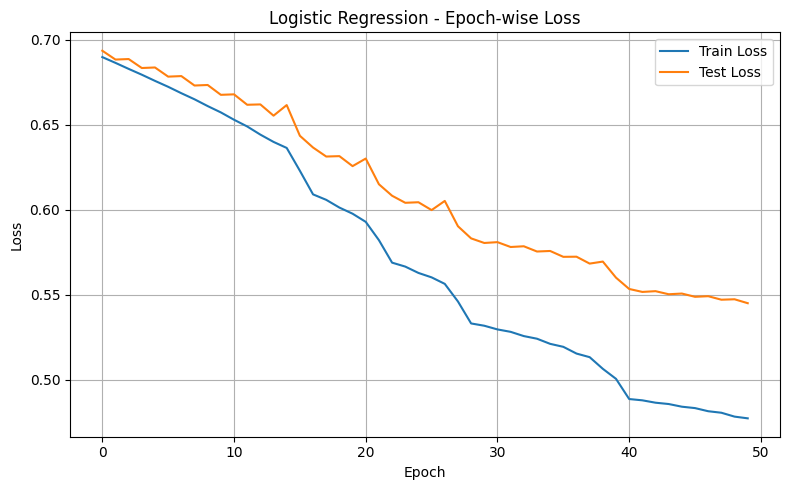

In [14]:
plot_losses(*track_logistic(), "Logistic Regression")

<h2>Logistic Regression Loss Curves When Dataset is 5000 and Vectorizer : Tfidf</h2>

              precision    recall  f1-score   support

           0       0.84      0.84      0.84      1242
           1       0.84      0.84      0.84      1258

    accuracy                           0.84      2500
   macro avg       0.84      0.84      0.84      2500
weighted avg       0.84      0.84      0.84      2500



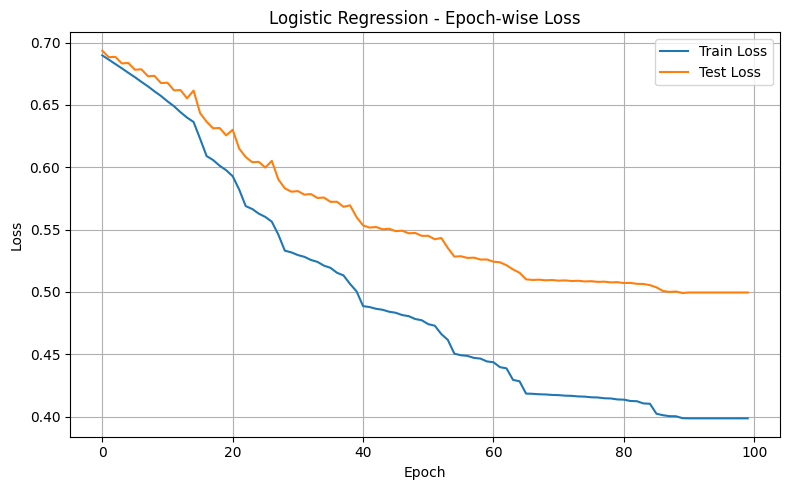

In [15]:
n_epochs = 100

def track_logistic():
    clf = LogisticRegression(max_iter=1, warm_start=True, solver='lbfgs')
    train_losses, test_losses = [], []
    for _ in range(n_epochs):
        clf.fit(X_train, y_train)
        train_losses.append(log_loss(y_train, clf.predict_proba(X_train)))
        test_losses.append(log_loss(y_test, clf.predict_proba(X_test)))
    lr_preds = clf.predict(X_test)
    print(classification_report(y_test, lr_preds))
    return train_losses, test_losses
def plot_losses(train_loss, test_loss, title):
    plt.figure(figsize=(8, 5))
    plt.plot(train_loss, label='Train Loss')
    plt.plot(test_loss, label='Test Loss')
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"{title} - Epoch-wise Loss")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()
plot_losses(*track_logistic(), "Logistic Regression")

<h2>Logistic Regression Loss Curves When Dataset is 50000 and Vectorizer : Tfidf</h2>

In [16]:
X = tfidf.fit_transform(df_old["lemmatized"])
y = df_old["sentiment"].values
X_train_new,X_test_new,y_train_new,y_test_new = train_test_split(X,y,test_size = 0.5,random_state=42)
print(X_train_new.shape,X_test_new.shape,y_train_new.shape,y_test_new.shape)

(25000, 203415) (25000, 203415) (25000,) (25000,)


In [17]:
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train_new, y_train_new)
lr_preds = lr_model.predict(X_test_new)
print(classification_report(y_test_new, lr_preds))

              precision    recall  f1-score   support

           0       0.89      0.88      0.88     12480
           1       0.88      0.89      0.89     12520

    accuracy                           0.89     25000
   macro avg       0.89      0.89      0.89     25000
weighted avg       0.89      0.89      0.89     25000



              precision    recall  f1-score   support

           0       0.89      0.87      0.88     12480
           1       0.87      0.89      0.88     12520

    accuracy                           0.88     25000
   macro avg       0.88      0.88      0.88     25000
weighted avg       0.88      0.88      0.88     25000



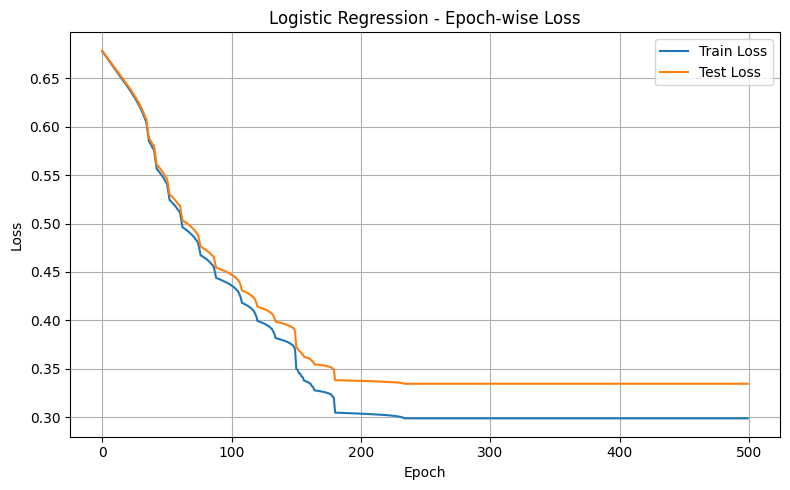

In [18]:
n_epochs = 500

def track_logistic():
    clf = LogisticRegression(max_iter=1, warm_start=True, solver='lbfgs')
    train_losses, test_losses = [], []
    for _ in range(n_epochs):
        clf.fit(X_train_new, y_train_new)
        train_losses.append(log_loss(y_train_new, clf.predict_proba(X_train_new)))
        test_losses.append(log_loss(y_test_new, clf.predict_proba(X_test_new)))
    lr_preds = clf.predict(X_test_new)
    print(classification_report(y_test_new, lr_preds))
    return train_losses, test_losses
def plot_losses(train_loss, test_loss, title):
    plt.figure(figsize=(8, 5))
    plt.plot(train_loss, label='Train Loss')
    plt.plot(test_loss, label='Test Loss')
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"{title} - Epoch-wise Loss")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()
plot_losses(*track_logistic(), "Logistic Regression")

<h2>Improvements For Check</h2>

<h3>min_df and max_df</h3>

In [19]:
vectorizer_new = TfidfVectorizer(
    min_df=20,       
    max_df=0.8,     
    stop_words='english'
)

In [20]:
X_imp = vectorizer_new.fit_transform(df_old["lemmatized"])
y_imp = df_old["sentiment"].values
X_train_imp,X_test_imp,y_train_imp,y_test_imp = train_test_split(X_imp,y_imp,test_size = 0.5,random_state=42)
print(X_train_imp.shape,X_test_imp.shape,y_train_imp.shape,y_test_imp.shape)

(25000, 15877) (25000, 15877) (25000,) (25000,)


              precision    recall  f1-score   support

           0       0.89      0.86      0.88     12480
           1       0.87      0.89      0.88     12520

    accuracy                           0.88     25000
   macro avg       0.88      0.88      0.88     25000
weighted avg       0.88      0.88      0.88     25000



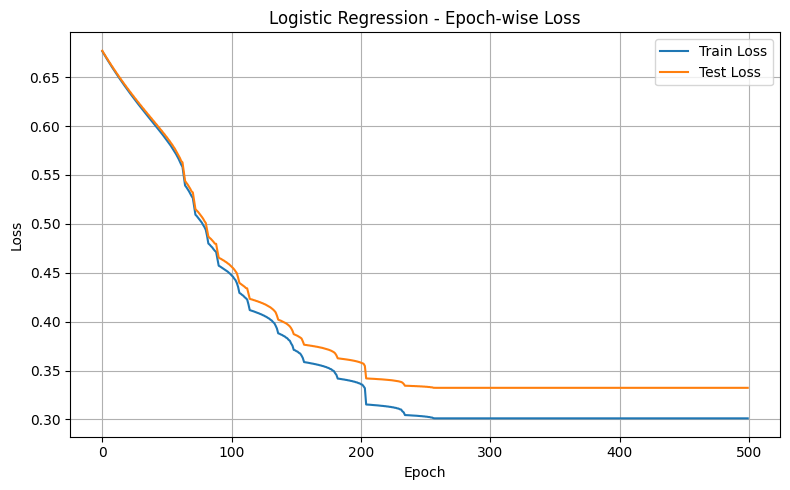

In [21]:
n_epochs = 500

def track_logistic():
    clf = LogisticRegression(max_iter=1, warm_start=True, solver='lbfgs')
    train_losses, test_losses = [], []
    for _ in range(n_epochs):
        clf.fit(X_train_imp, y_train_imp)
        train_losses.append(log_loss(y_train_imp, clf.predict_proba(X_train_imp)))
        test_losses.append(log_loss(y_test_imp, clf.predict_proba(X_test_imp)))
    lr_preds = clf.predict(X_test_imp)
    print(classification_report(y_test_imp, lr_preds))
    return train_losses, test_losses
def plot_losses(train_loss, test_loss, title):
    plt.figure(figsize=(8, 5))
    plt.plot(train_loss, label='Train Loss')
    plt.plot(test_loss, label='Test Loss')
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"{title} - Epoch-wise Loss")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()
plot_losses(*track_logistic(), "Logistic Regression")

<h3>penalty and solver</h3>

              precision    recall  f1-score   support

           0       0.87      0.76      0.82      1242
           1       0.79      0.89      0.84      1258

    accuracy                           0.83      2500
   macro avg       0.83      0.83      0.83      2500
weighted avg       0.83      0.83      0.83      2500



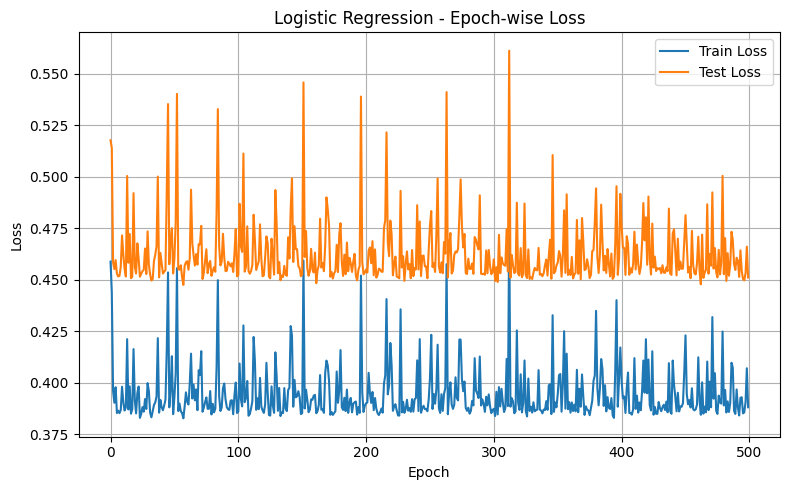

In [22]:
n_epochs = 500

def track_logistic():
    clf = LogisticRegression(max_iter=1, warm_start=True, solver='saga',penalty='elasticnet',l1_ratio=0.5,C=1.0)
    train_losses, test_losses = [], []
    for _ in range(n_epochs):
        clf.fit(X_train, y_train)
        train_losses.append(log_loss(y_train, clf.predict_proba(X_train)))
        test_losses.append(log_loss(y_test, clf.predict_proba(X_test)))
    lr_preds = clf.predict(X_test)
    print(classification_report(y_test, lr_preds))
    return train_losses, test_losses
def plot_losses(train_loss, test_loss, title):
    plt.figure(figsize=(8, 5))
    plt.plot(train_loss, label='Train Loss')
    plt.plot(test_loss, label='Test Loss')
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"{title} - Epoch-wise Loss")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()
plot_losses(*track_logistic(), "Logistic Regression")